<a href="https://colab.research.google.com/github/michalis0/Business-Intelligence-and-Analytics/blob/master/Assignment/Assignment_2026_v1.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import plotly.graph_objs as go
import statistics

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, recall_score, precision_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

warnings.filterwarnings('ignore')
%matplotlib inline

<div>
<td>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/2/2b/Logo_Universit%C3%A9_de_Lausanne.svg/2000px-Logo_Universit%C3%A9_de_Lausanne.svg.png" style="padding-right:10px;width:240px;float:left"/></td>
<h2 style="white-space: nowrap">Business Intelligence and Analytics Personal Assignment</h2></td>
<hr style="clear:both">
<p style="font-size:0.85em; margin:2px; text-align:justify">
last updated 20.04.2026, v1

</div>

# Part 1: Venture Capital — Mapping the Next Unicorn

##  Context ✨

You have been hired as a **Junior Data Scientist at VenturAI**, a boutique venture capital firm that specializes in identifying high-potential startups before they become "Unicorns."

The Senior Partner has provided a snapshot of the global startup ecosystem: `investments_VC.csv`. This dataset contains historical information on thousands of companies across various markets and geographical locations.

**Your Mission:** Clean the data, explore the trends in startup funding, and build predictive or descriptive models to help the firm understand the key drivers of startup success.

---

Dataset Overview:

* Company Info: `name`, `market`, `status` (Operating, Acquired, Closed).

* Location: `country_code`, `state_code`, `region`, `city`.

* Timeline: `founded_at`, `first_funding_at`, `last_funding_at`.

* Financials: `funding_total_usd`, `funding_rounds`.

* Funding Types: `seed`, `venture`, `angel`, `round_A`, `round_B`, etc.

In [27]:
path = 'https://storage.googleapis.com/project_bia_unil/investments_VC.csv'
data_venture = pd.read_csv(path, encoding='latin1')
data_venture.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
#question 1

#pour trouver le nombres de ligne null
data_venture.isnull().any(axis=1).sum()

np.int64(32454)

In [6]:
data_venture.dtypes

,0
permalink,object
name,object
homepage_url,object
category_list,object
market,object
funding_total_usd,object
status,object
country_code,object
state_code,object
region,object


In [29]:
data_venture.shape

(54294, 39)

## 🧹 Exercise 1: Data Cleaning & Preprocessing

Data scientists spend nearly 80% of their time cleaning data! In this exercise, you must prepare the dataset for analysis. Raw datasets often come with inconsistencies that can bias your findings.

**Objective:** Build a clean, numeric-ready dataframe named `data_venture`.

**Tasks:**
*   **Normalization:** Strip redundant whitespace from strings and column headers.
*   **Data Type Correction:** Convert `funding_total_usd` into a clean float, removing any non-numeric distractions.
*   **Handling Missingness:** Categorize missing `market` and `status` values appropriately as 'N/A'.
*   **Filtering:** Focus on investment-ready entries (funding > 0).

The Venture Capital dataset contains information on thousands of startups, but it requires significant cleaning before it can be used for analysis. Your first task is to prepare the data by handling numeric conversions and missing values to ensure the funding data is consistent.

Your mission:

* Strip any leading or trailing whitespace from column names and string values.
* Clean the funding_total_usd column by removing commas and other non-numeric characters, then converting it to a numeric float.
* Handle missing values in the market and status columns by labeling them as 'N/A'.
* Filter the dataset to include only startups with a total funding amount greater than zero.

In [30]:
# Data cleaning

### The funding_total_usd column is currently stored as a string with commas and extra whitespace.

# Step 1: Strip any leading/trailing whitespace from the column name and its values.

#enleve les espaces pour noms
data_venture.columns = data_venture.columns.str.strip()

#enleve les espaces pour object string
for col in data_venture.select_dtypes(include='object').columns:
    data_venture[col] = data_venture[col].str.strip()


# Step 2: Remove commas, spaces, and hyphens, then convert the column to a numeric float64 type, handling errors by setting to 0.
#enleve les espaces, ca - et virgule
data_venture['funding_total_usd'] = data_venture[
    'funding_total_usd'
].str.replace(',', '').str.replace(' ', '').str.replace('-', '')

#converti en numérique
data_venture['funding_total_usd'] = pd.to_numeric(
    data_venture['funding_total_usd'],
    errors='coerce'
)


# Step 3: Handle "Unknown" or missing values in the market and status columns by labeling them as 'N/A'. remove any heading and trailing whitespace
#rempli valeurs inconnu par N/A
data_venture['market'] = data_venture['market'].fillna('N/A')
data_venture['status'] = data_venture['status'].fillna('N/A')

#remplace unknown par N/A
data_venture['market'] = data_venture['market'].replace('Unknown', 'N/A')
data_venture['status'] = data_venture['status'].replace('Unknown', 'N/A')

#enleve espace de tout cotés
data_venture['market'] = data_venture['market'].str.strip()
data_venture['status'] = data_venture['status'].str.strip()


# Step 4: Drop any rows where the startup has 0 total funding, as these do not fit our "Venture Capital" investment criteria.
#enleve ceux qui on pas de funding
data_venture = data_venture[
    data_venture['funding_total_usd'] > 0
]

#question 2

54294 - data_venture.shape[0]




13387

In [9]:
# Question 3: Calculate the average total funding received by startups in the "Software," "Biotechnology," and "Mobile" markets.

### average over the 3 (trap, not to do average of previous answers)
#selectionner 3 markets
markets = ['Software', 'Biotechnology', 'Mobile']

#calculer average funding
average_funding = data_venture[
    data_venture['market'].isin(markets)
]['funding_total_usd'].mean()

average_funding

np.float64(17785425.50921237)

**Note on Funding Data**:

> Startups often go through multiple stages of funding, from initial Seed and Angel rounds to later-stage Venture rounds (Series A, B, C, etc.). The `funding_total_usd` represents the cumulative investment received. When analyzing performance, it is important to consider the timeline from founding to these investment milestones, as well as the current operational status of the company.

## 📊 Exercise 2: Exploratory Data Analysis (EDA)

Before diving into predictive modeling, you must understand the landscape of global startup funding. Your task is to extract meaningful insights by slicing the data across different dimensions.

**Mission Deliverables:**
1.  **Market Comparison:** Compare funding averages across competitive sectors like Software and BioTech.
2.  **Success Spotting:** Pinpoint the country-market hubs where 'Acquired' startups reach their highest valuation.
3.  **Failure Analysis:** Speed is everything in startups. Calculate the lead time to first funding for companies that didn't make it ('Closed').
4.  **Visual Trends:** Use a pie chart for market distribution and a time-series plot to track funding popularity over the last decade.

Before diving into deeper modeling, your supervisor wants a clear picture of the global startup ecosystem. You are tasked with analyzing funding trends across different markets and visualizing the success rates of various investment profiles.

Your mission:

* Calculate the average funding received by startups in specific major markets like Software, Biotechnology, and Mobile.
* Identify which country-market combinations have the highest median funding for startups that reached 'Acquired' status.
* Analyze the average time (in days) it takes for a startup to receive its first funding round, focusing on companies that eventually closed.
* Visualize the distribution of markets for 'Acquired' startups using a pie chart.
* Create a line plot tracking the annual sum of key funding types (Seed, Venture, Round A) over the last decade (2005-2014).

In [10]:
# Question 4: Identify which country-market combination has the highest median funding for "Acquired" startups.

#Group the data by country_code, status, and market.
#Calculate the mean and median funding for each group.
#Hint: Use the as_index=False parameter in your groupby to keep the columns accessible for visualization.

#garder que les start-ups aquired
acquired = data_venture[
    data_venture['status'] == 'acquired'
]

#grouper et calculer
funding_stats = acquired.groupby(
    ['country_code', 'market'],
    as_index=False
)['funding_total_usd'].agg(['mean', 'median'])

funding_stats

,country_code,market,mean,median
0,ARE,Social Media,5250000.0,5250000.0
1,ARG,E-Commerce,45000.0,45000.0
2,ARG,Finance,24120000.0,24120000.0
3,ARG,Games,600000.0,600000.0
4,ARG,Software,1500000.0,1500000.0
...,...,...,...,...
641,USA,World Domination,81299969.0,81299969.0
642,USA,iPad,4096080.0,4096080.0
643,USA,iPhone,14716176.4,11500000.0
644,USA,iPod Touch,2638000.0,2638000.0


In [11]:
# Question 5: What is the average days_to_funding for companies that are now "Closed"?

# The dates are currently strings. Convert founded_at and first_funding_at to datetime objects.
#Create a new column called days_to_funding, calculating the number of days between the date the company was founded and its first funding round.

#conevertir colonne en date time
data_venture['founded_at'] = pd.to_datetime(
    data_venture['founded_at'],
    errors='coerce'
)

data_venture['first_funding_at'] = pd.to_datetime(
    data_venture['first_funding_at'],
    errors='coerce'
)

#garder que les compagnies fermées
closed = data_venture[
    data_venture['status'] == 'closed'
]

#calculer jours jusque funding
closed['days_to_funding'] = (
    closed['first_funding_at'] - closed['founded_at']
).dt.days

#calculer moyenne des jours
closed['days_to_funding'].mean()


np.float64(751.973037747154)

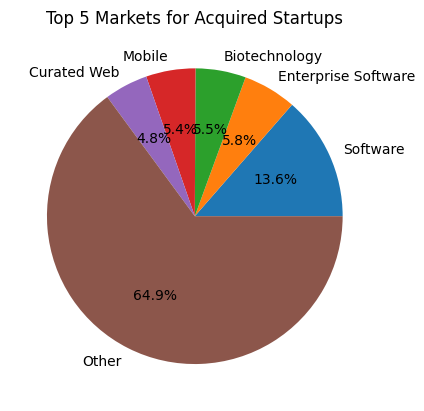

In [12]:
# Question 6: Create a pie chart showing the top 5 markets by count for acquired startups.

# Your firm wants to see the distribution of startups across markets, but only for those that have achieved "Acquired" status.

# The Catch: Group all other markets into a single category labeled "Other".

#garder seulement les start up acquired
acquired = data_venture[
    data_venture['status'] == 'acquired'
]

#compter les marchés
market_counts = acquired['market'].value_counts()

#garder que les 5 meilleures
top_5 = market_counts.head(5)

#grouper les autre (hors du top 5) en autre
other = market_counts.iloc[5:].sum()

#ajouter catégorie autre
top_5['Other'] = other

#créer grosse tarte <= pie chart
plt.pie(
    top_5,
    labels=top_5.index,
    autopct='%1.1f%%'
)

plt.title('Top 5 Markets for Acquired Startups')

plt.show()


In [13]:
data_venture[['seed', 'venture', 'round_A']].head()

,seed,venture,round_A
0,1750000.0,0.0,0.0
1,0.0,4000000.0,0.0
2,40000.0,0.0,0.0
3,1500000.0,0.0,0.0
4,0.0,0.0,0.0


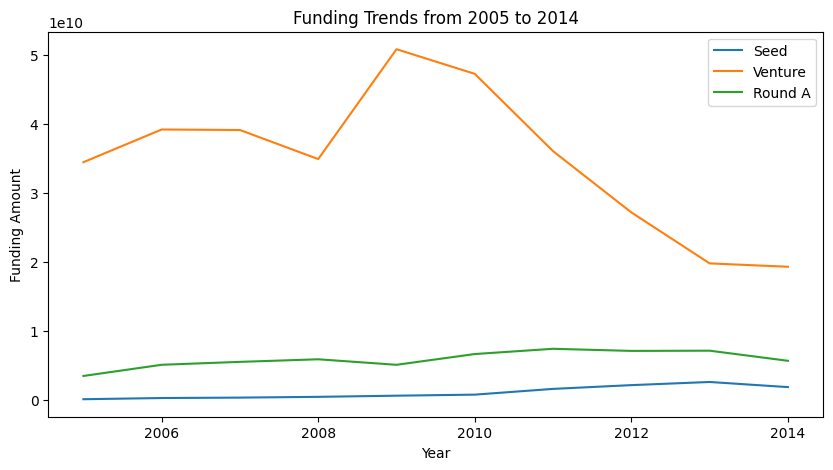

In [14]:
# Question 7: Create a line plot showing the annual sum of seed, venture, and round_A funding from the year 2005 to 2014.
# We need to track how different funding rounds have changed in popularity over time.


# Filter for the years 2005 to 2014
# Group by year and sum the funding rounds
# Create the line plot

#convertir colonne date en date time
data_venture['first_funding_at'] = pd.to_datetime(
    data_venture['first_funding_at'],
    errors='coerce'
)

#créer colonne année
data_venture['year'] = data_venture[
    'first_funding_at'
].dt.year

#garder année 2005 à 2014
filtered_data = data_venture[
    (data_venture['year'] >= 2005) &
    (data_venture['year'] <= 2014)
]

#grouper par année et sommer les funding rounds
yearly_funding = filtered_data.groupby('year')[
    ['seed', 'venture', 'round_A']
].sum()

#créer line plot
plt.figure(figsize=(10,5))

plt.plot(yearly_funding.index, yearly_funding['seed'], label='Seed')

plt.plot(yearly_funding.index, yearly_funding['venture'], label='Venture')

plt.plot(yearly_funding.index, yearly_funding['round_A'], label='Round A')

plt.title('Funding Trends from 2005 to 2014')

plt.xlabel('Year')

plt.ylabel('Funding Amount')

plt.legend()

plt.show()



## 🧬 Exercise 3: Unsupervised Learning (Clustering)

Not all startups are equal. VenturAI proposes to group them based on their *investment signatures*. By clustering companies with similar funding milestones, we can identify hidden archetypes of high-potential companies.

**Mission Requirements:**
*   Use **Hierarchical Clustering** to define distinct funding clusters.
*   Visualize the investment distance between startups using a **Dendrogram**.
*   Identify the common traits of startups that share a logic of investment.

VenturAI aims to identify distinct profiles of startups based on their funding behavior. You propose using unsupervised learning to group startups into clusters that share similar investment patterns, regardless of their market sector.

Your mission:

* Perform hierarchical clustering to identify distinct startup groups based on their funding histories.
* Analyze the similarities between companies in different clusters to understand common paths to success or failure.
* Visualize the relationships between these groups using a dendrogram to assist in defining the firm's investment strategy.

**note**: you can use `n_clusters = 4` and `Eucledian` distance with `Ward` linkage.


In [1]:
# Agglomerative Clustering for Venture Capital
# Question 8: Find the number of values in each clustering label

#selectionner les bonnes colonnes => funding
clustering_data = data_venture[
    ['seed', 'venture', 'round_A']
]

#enlever les données manquantes
clustering_data = clustering_data.dropna()

#créer le modèle clustering
model = AgglomerativeClustering(
    n_clusters=4,
    metric='euclidean',
    linkage='ward'
)

#créer cluster
clusters = model.fit_predict(clustering_data)

#ajouter labels
clustering_data['cluster'] = clusters

#compter les valeurs dans chaqu'une des clusters
clustering_data['cluster'].value_counts()



NameError: name 'data_venture' is not defined

In [3]:
# Dendrogram for Startup Investment Profiles
#créer la figure pour avoir la bonne taille <= je trouve pas ca très lisible
plt.figure(figsize=(10,5))

#créer le dandogramme
dendrogram(linked)

plt.title('Dendrogram for Startup Investment Profiles')

plt.xlabel('Startups')

plt.ylabel('Euclidean Distance')

plt.show()


NameError: name 'linked' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
# Agglomerative Clustering for "Finance|FinTech" Startups


## 📈 Exercise 4: Supervised Learning — Impact of Momentum

A key question for our firm: **"Does the number of previous funding rounds accurately predict the final total funding received?"** Momentum is often a predictor of scale. You will test this using the simplest possible predictive model.

**Mission Goals:**
*   **Heatmap Discovery:** Visualize correlations between different funding stages.
*   **Single Regression:** Predict `funding_total_usd` using `funding_rounds` as a single feature.
*   **Error Metrics:** Quantify the model's reliability using R², MSE, and MAE.

One of the partners asks: "Does the number of funding rounds have a measurable impact on the total funding a startup receives?" You decide to test this relationship using a basic regression model.

**Your mission:**
* Plot a heatmap of correlations between numeric funding columns.
* Model `funding_total_usd` as a function of `funding_rounds` (with `test_size = 0.3`, `random_state = 123` and `shuffle=True`).
* Use `MinMaxScaler` and find the $R^2$, the MSE and the MAE.

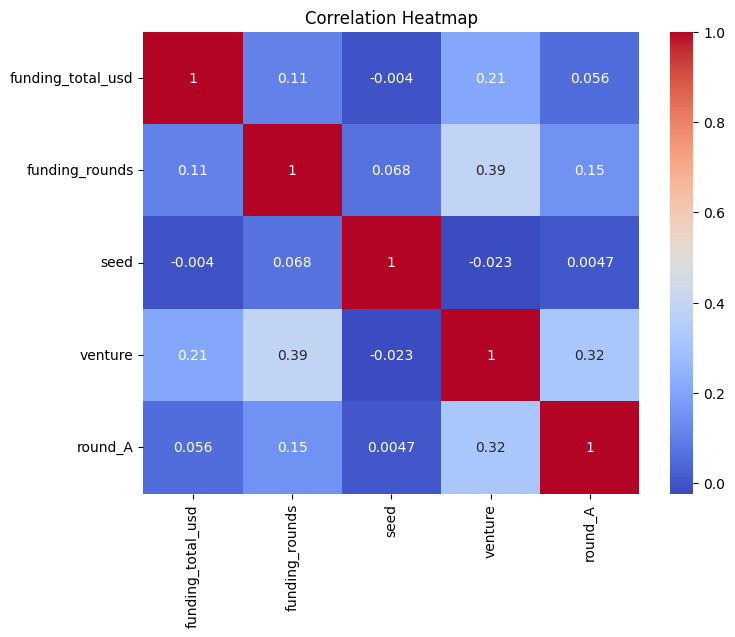

In [15]:
# Question 9: Plot heatmap of correlations
#importer denouveau <= m'evite de le refaire tout en hauta chaque fois
import seaborn as sns
import matplotlib.pyplot as plt

#selectionner le colonne numérique
funding_columns = data_venture[
    ['funding_total_usd',
     'funding_rounds',
     'seed',
     'venture',
     'round_A']
]

#calculer la matrice
correlation_matrix = funding_columns.corr()

#créer la heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()


In [16]:
# Seperate features and labels

#separer feature
X = data_venture[['funding_rounds']]

#separer labels
y = data_venture['funding_total_usd']

In [17]:
# Split data into train and test sets

#denouveau du importer car marche pas sinon
from sklearn.model_selection import train_test_split

#séparer le data en train et tes
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=123,
    shuffle=True
)


In [18]:
# Scale the data

#routine
from sklearn.preprocessing import MinMaxScaler

#créer scaler
scaler = MinMaxScaler()

#scale la train data
X_train = scaler.fit_transform(X_train)

#scale la test data
X_test = scaler.transform(X_test)


In [19]:
# Create linear regression model and fit into the training data

#routine
from sklearn.linear_model import LinearRegression

#créer modele
model = LinearRegression()

#modele trai
model.fit(X_train, y_train)

#faire prédictio
y_pred = model.predict(X_test)


In [20]:
# Question 10: Print out the R2, MSE and MAE score

#routine
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

#calculer score
r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

#print resultats
print("R2 Score:", r2)

print("MSE:", mse)

print("MAE:", mae)




R2 Score: 0.09971614639606752
MSE: 2197077610582926.0
MAE: 16987153.740982916


## 🤖 Exercise 5: Multivariate Complexity

Relationships in the real world are rarely one-dimensional. To improve predictability, we must incorporate categorical indicators like sectoral demand and geographical advantages.

**Mission Goals:**
*   **Encoding:** Transform high-cardinality categorical data (`market` and `country_code`) into numeric inputs.
*   **Multivariate Modeling:** Train a model using all available indicators.
*   **Performance Comparison:** Compare accuracy against the simpler model to justify the inclusion of complex features.

Real-life success is rarely determined by a single factor. You now create a new model to include other variables like the market sector and the geographic region.

**Your mission:**
* Transform the `market` column using `LabelEncoder` and the `country_code` column using `One-Hot` encoding.
* Build a multivariate regression model using multiple features to predict total funding (with `test_size = 0.3`, `random_state = 123` and `shuffle=True`).
* Compare its performance with the previous simple regression model.

In [21]:
# Seperate features and labels, and transform the columns market and country_code

#routine
from sklearn.preprocessing import LabelEncoder

#encoder la colonne market
label_encoder = LabelEncoder()

data_venture['market_encoded'] = label_encoder.fit_transform(
    data_venture['market']
)

#transformer pays en code 1/0
country_encoded = pd.get_dummies(
    data_venture['country_code'],
    prefix='country'
)

#créer feature
X = pd.concat(
    [
        data_venture[['funding_rounds', 'market_encoded']],
        country_encoded
    ],
    axis=1
)

#créer label
y = data_venture['funding_total_usd']





In [22]:
# Split data into train and test sets, create linear regression model and fit into the training data

#routine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

#split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=123,
    shuffle=True
)

#scale la data
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

#créer model
model = LinearRegression()

#train modele
model.fit(X_train, y_train)

#prédire les valeurs
y_pred = model.predict(X_test)




In [23]:
# Question 11: Print out the R2, MSE and MAE score

#routine
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

#calculer les scores
r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

#print resultat
print("R2 Score:", r2)

print("MSE:", mse)

print("MAE:", mae)



R2 Score: 0.09496407126060158
MSE: 2208674706145781.0
MAE: 17167966.911556534


# Part 2: Association Rules - Turn movies ratings into bussiness insights!

Lights, Camera, Data!

Are you a movie fan? I bet you are! Have you ever wondered how streaming platforms like Netflix seem to know exactly which movie you'll love next? You might have heard that they use recommendation algorithms and wondered how they work.

In this assignment, you'll explore how **association rules** can be used to develop a simple recommendation algorithm. The idea is simple: by analyzing which movies are frequently watched together, we can uncover patterns and use these insights to suggest movies based on a user's viewing history.

Now, let's dive in and make it happen!

## Exercise 1: Data Processing

We will use a subset of MoviesLens dataset, which consists of user ratings for a list of movies and information about the movies themselves (i.e., title and genres).

First, you need to load the ratings data from the URL below, and try to print out the size of the dataset, the number of users who provided ratings, and the number of movies that have been rated.

URL = "https://storage.googleapis.com/project_bia_unil/ratings.csv"

The `ratings` dataset contains four columns:

- `userID`: The ID of the user.
- `movieID`: The ID of the movie being rated.
- `rating`: The rating given by the user for the corresponding movie.
- `timestamp`: The timestamp when the rating was recorded.

In [25]:
#pour importer le data set depuis l'url
import pandas as pd

#charger dataset
url = "https://storage.googleapis.com/project_bia_unil/ratings.csv"

ratings = pd.read_csv(url)


In [26]:
# Print the first 5 rows of the dataframe

#facile
ratings.head()


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [27]:
# Print the shape of the dataframe

#de meme
ratings.shape


(100836, 4)

In [28]:
# Print the number of ratings available

#comme les précédents
len(ratings)


100836

In [29]:
# Print the number of users who provided ratings

#pour user
ratings['userId'].nunique()


610

In [30]:
# Print the number of movies have been rated

#pour filme
ratings['movieId'].nunique()


9724

Now, we need to transform the dataset into a matrix of size `n_users` × `n_movies`, where each row represents a user's ratings for all movies. If a user has not rated a movie, the rating will be 0.

To create this matrix, we will use the `pivot` function from pandas.

In [31]:
#créer la matrice
movie_matrix = ratings.pivot(
    index='userId',
    columns='movieId',
    values='rating'
)

movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


You can see that there are a lot of NaN values because each user rates only a subset of movies (those they have watched). We need to fill these NaN values with 0s.

In [32]:
# Replace NaN values with 0


movie_matrix = movie_matrix.fillna(0)

movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Next, we don’t just want to identify movies that are frequently watched together—we want to focus on the ones that people actually enjoy. To do this, we'll consider a rating of 3 or higher as an indicator that a viewer liked the movie.

Therefore, we need to map ratings ≥ 3 to `True` (liked) and ratings below 3 to `False` (not liked).

In [33]:
#convertir les notes en liked et not liked
movie_matrix = movie_matrix >= 3

movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,True,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Now, we are ready to apply the association rules!!

## Exercise 2: Association Rules



We will apply the **Apriori algorithm** to identify interesting association rules.

First, we need to find the frequent itemsets using the following configurations:

`min_support = 0.1`
`max_len = 2`

In [34]:
# Find the frequent itemsets

#routine
from mlxtend.frequent_patterns import apriori

# Find frequent itemsets
frequent_itemsets = apriori(
    movie_matrix,
    min_support=0.1,
    use_colnames=True,
    max_len=2
)

frequent_itemsets.head()


,support,itemsets
0,0.326230,(1)
1,0.145902,(2)
2,0.162295,(6)
3,0.193443,(10)
4,0.122951,(16)


In [35]:
# Question 12: Find the number of itemsets

len(frequent_itemsets)


2929

Now, we will mine the association rules from the frequent itemsets found above using `metric='lift'` and `min_threshold=1`.

In [36]:
# Find association rules

#routine
from mlxtend.frequent_patterns import association_rules

# Find association rules
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1
)

rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(32),(1),0.280328,0.326230,0.150820,0.538012,1.649182,1.0,0.059368,1.458415,0.546969,0.330935,0.314324,0.500162
1,(1),(32),0.326230,0.280328,0.150820,0.462312,1.649182,1.0,0.059368,1.338456,0.584233,0.330935,0.252870,0.500162
2,(1),(34),0.326230,0.170492,0.111475,0.341709,2.004252,1.0,0.055856,1.260093,0.743667,0.289362,0.206408,0.497777
3,(34),(1),0.170492,0.326230,0.111475,0.653846,2.004252,1.0,0.055856,1.946448,0.604046,0.289362,0.486244,0.497777
4,(1),(47),0.326230,0.313115,0.132787,0.407035,1.299955,1.0,0.030640,1.158391,0.342465,0.262136,0.136734,0.415559


Now, let's map the movie IDs with their titles so we can identify them.

First, let's load the `movies` dataset from this URL: "https://storage.googleapis.com/project_bia_unil/movies.csv"

You will see that the `movies` dataset has 3 columns:
- `movieID`: The ID of the movie.
- `title`: The title of the movie.
- `genres`: The genres of the movie.

In [37]:
#routine
import pandas as pd

#charger movies dataset
movies = pd.read_csv(
    "https://storage.googleapis.com/project_bia_unil/movies.csv"
)

#pour voir la tete du truc
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In the following cell, we provide the code to map movie IDs with their titles. We assume that you are using the variable `rules` to store the association rules. If you used a different variable name, please update the code accordingly.

In [38]:
# Map antecedents and consequents with movie names
# rules[rules["lift"] > 1].sort_values(by="lift", ascending=False)
# rules.head()

#créer movie id en titre de dictionnaire
movie_dict = dict(
    zip(movies['movieId'], movies['title'])
)

#map de antecedents et consequents avec nom de film
rules['antecedents'] = rules['antecedents'].apply(
    lambda x: [movie_dict[i] for i in x]
)

rules['consequents'] = rules['consequents'].apply(
    lambda x: [movie_dict[i] for i in x]
)

#montrer règles avec lift > 1
rules[rules['lift'] > 1].sort_values(
    by='lift',
    ascending=False
).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
5166,[Harry Potter and the Prisoner of Azkaban (2004)],[Harry Potter and the Chamber of Secrets (2002)],0.142623,0.142623,0.106557,0.747126,5.238473,1.0,0.086216,3.390537,0.943698,0.596330,0.705061,0.747126
5167,[Harry Potter and the Chamber of Secrets (2002)],[Harry Potter and the Prisoner of Azkaban (2004)],0.142623,0.142623,0.106557,0.747126,5.238473,1.0,0.086216,3.390537,0.943698,0.596330,0.705061,0.747126
4235,[Austin Powers: International Man of Mystery (...,[Austin Powers: The Spy Who Shagged Me (1999)],0.137705,0.144262,0.101639,0.738095,5.116342,1.0,0.081774,3.267362,0.933031,0.563636,0.693943,0.721320
4234,[Austin Powers: The Spy Who Shagged Me (1999)],[Austin Powers: International Man of Mystery (...,0.144262,0.137705,0.101639,0.704545,5.116342,1.0,0.081774,2.918537,0.940180,0.563636,0.657363,0.721320
5021,[Harry Potter and the Chamber of Secrets (2002)],[Harry Potter and the Sorcerer's Stone (a.k.a....,0.142623,0.157377,0.111475,0.781609,4.966475,1.0,0.089030,3.858326,0.931504,0.591304,0.740820,0.744971


Now, we are ready to find out the most interesting association rules (i.e a pair of movies that are watched together) in term of the `lift` metric

In [39]:
# Question 13: Find the most interesting rule

#trouver regle avec plus grand lift
rules.sort_values(
    by='lift',
    ascending=False
).head(1)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
5166,[Harry Potter and the Prisoner of Azkaban (2004)],[Harry Potter and the Chamber of Secrets (2002)],0.142623,0.142623,0.106557,0.747126,5.238473,1.0,0.086216,3.390537,0.943698,0.59633,0.705061,0.747126


In [40]:
# Question 14: Find the movie that is the most frequently watched together with "Beauty and the beast (1991)"

#filtrer regles contenants Beauty and the Beast (1991)
beauty_rules = rules[
    rules['antecedents'].apply(
        lambda x: 'Beauty and the Beast (1991)' in x
    )
]

#trier par lift
beauty_rules.sort_values(
    by='lift',
    ascending=False
).head(1)



,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2678,[Beauty and the Beast (1991)],[Aladdin (1992)],0.22459,0.277049,0.185246,0.824818,2.977152,1.0,0.123023,4.126844,0.856461,0.585492,0.757684,0.746728


# Part 3: Binary Classification

You are working at a leading Tour & Travel Company, and there’s trouble on the horizon — some customers are slipping away, never to book again! Your job is to predict which customers are at risk of churning and help the company keep them engaged.

Using historical customer data, you’ll use binary classification algorithms to identify potential churners before they disappear.

First, you need to load the dataset from this URL: "https://storage.googleapis.com/project_bia_unil/travel.csv"

The dataset consists of following columns:
- `Age`: Age of customer.
- `FrequentFlyer`: Whether the customer takes frequent flights.
- `AnnualIncomeClass`: Class of the customer's annual income.
- `ServicesOpted`: Number of times services opted during recent years.
- `AccountSyncedToSocialMedia`: Whether company account of the user is synchronised to their social media.
- `BookedHotelOrNot`: Whether the customer books hotels using company services.
- `Target`: Whether the customer is a churner (1 for yes, 0 for no).

Try to print out the number of samples available in the dataset and types of each columns.

In [6]:
#routine
import pandas as pd

#charger le dataset
url = "https://storage.googleapis.com/project_bia_unil/travel.csv"

travel = pd.read_csv(url)

In [7]:
# Print the first 5 rows

travel.head()


,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
0,36,No,Middle Income,6,No,Yes,0
1,34,Yes,Low Income,5,Yes,No,1
2,37,No,Middle Income,3,Yes,No,0
3,30,No,Middle Income,2,No,No,0
4,30,No,Low Income,1,No,No,0


In [8]:
# Print the number of samples in the dataset

travel.shape


(960, 7)

In [9]:
# Print the column types

travel.dtypes


,0
Age,int64
FrequentFlyer,object
AnnualIncomeClass,object
ServicesOpted,int64
AccountSyncedToSocialMedia,object
BookedHotelOrNot,object
Target,int64


## Exercise 1: Preprocess


First, we want to convert the columns with an object data type to
a **categorical** one and visualize the correlation heatmap of the dataset's features.

In [10]:
#routine
from sklearn.preprocessing import LabelEncoder

#créer encoder
label_encoder = LabelEncoder()

#convertir objet de colonne
travel['FrequentFlyer'] = label_encoder.fit_transform(
    travel['FrequentFlyer']
)

travel['AnnualIncomeClass'] = label_encoder.fit_transform(
    travel['AnnualIncomeClass']
)

travel['AccountSyncedToSocialMedia'] = label_encoder.fit_transform(
    travel['AccountSyncedToSocialMedia']
)

travel['BookedHotelOrNot'] = label_encoder.fit_transform(
    travel['BookedHotelOrNot']
)

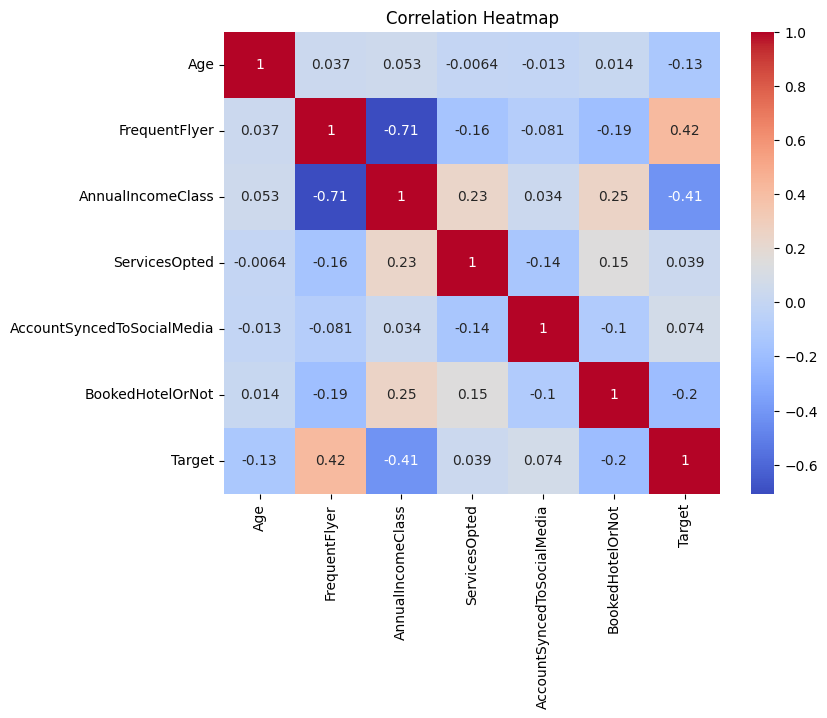

In [11]:
# Question 15: Plot heatmap of correlations

#routine
import seaborn as sns
import matplotlib.pyplot as plt

#calculer correlation
correlation_matrix = travel.corr()

#créer map chaude => heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()


Now, let's separate the dataset into features (X) and labels (y). Then, split the data into train and test sets using `train_test_split` function from Sklearn with `test_size=0.2`, `random_state=42`, and set `stratify=y` to preserve the label distribution in both sets.

In [12]:
# Seperate the dataset into features and labels

#fetaure
X = travel.drop('Target', axis=1)

#labels
y = travel['Target']


In [13]:
# Split into train and test sets

#routine
from sklearn.model_selection import train_test_split

#separer la data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Before building any model, it's useful to establish a simple reference point. Imagine predicting the most frequent class for every single observation—no learning, just repetition. The accuracy you'd get from that naive approach is called the baseline accuracy. It’s the minimum benchmark any meaningful model should aim to outperform.

In [14]:
# Question 16: Calculate baseline accuracy

#routine¨
from sklearn.metrics import accuracy_score

#trouver la class la plus fréquente
baseline_prediction = y_train.mode()[0]

#créer predictions en utilisant la class la plus frequente
baseline_predictions = [baseline_prediction] * len(y_test)

#calculer la precision de la baseline
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("Baseline Accuracy:", baseline_accuracy)


Baseline Accuracy: 0.765625


Now, let's standardize the features using `StandardScaler` from Sklearn.

In [15]:
# Standardise features

#routine
from sklearn.preprocessing import StandardScaler

#créer scaler
scaler = StandardScaler()

#standardiser la data de training
X_train = scaler.fit_transform(X_train)

#standardiser la data de test
X_test = scaler.transform(X_test)


## Exercise 2: Logistic regression

First, try use logistic regression for use our data. Use LogisticRegression with the following setting:
`penalty='l2', solver='lbfgs', max_iter=1000, random_state=30`

In [16]:
# Logistic Regression

#routine
from sklearn.linear_model import LogisticRegression

#créer modele de regression logistic
log_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=30
)

#train modele
log_model.fit(X_train, y_train)

#predictions
y_pred = log_model.predict(X_test)


In [17]:
# Question 17: Find the test accuracy

#routine
from sklearn.metrics import accuracy_score

#calculer precision
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)


Test Accuracy: 0.8541666666666666


Next, train a logistic regression classifier with cross-validation. Use 5 folds and 9 values in the logscale between $10^{-4}$ and $10^4$ for the regularizer parameter. For the rest of the arguments, we use the same values as we used for the logistic regression with no cross validation.

__Important:__ Set the following values for the arguments:
`
solver='lbfgs', max_iter=1000, random_state=42, cv=4, Cs=*9*
`

In [18]:
# Train a logistic regression classifier with cross-validation

# error in the question cv = 4 or 5 ?
# no problem because bothe give the same result

#routine
import numpy as np
from sklearn.linear_model import LogisticRegressionCV

#créer valeurs entre 10 puissance -4 et 10 puissance 4
c_values = np.logspace(-4, 4, 9)

#regression logistique avec cross-validation
log_cv = LogisticRegressionCV(
    Cs=c_values,
    cv=4,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

#train test
log_cv.fit(X_train, y_train)

#predictions
y_pred_cv = log_cv.predict(X_test)


In [19]:
# Question 18: Find the value of the test accuracy

#routine
from sklearn.metrics import accuracy_score

#calculer precision
accuracy_cv = accuracy_score(y_test, y_pred_cv)

print("Cross-Validation Accuracy:", accuracy_cv)


Cross-Validation Accuracy: 0.8541666666666666


## Exercise 3: KNN classifier

Use the KNeighborClassifier from sklearn using the following setting:
`n_neighbors=7, p=2, weights='uniform', algorithm="kd_tree"`

In [20]:
# KNeighborClassifier

#y_pred_knn = knn_classifier.predict(X_test_scaled)

#routine
from sklearn.neighbors import KNeighborsClassifier

#créer KNN classificateur
knn_classifier = KNeighborsClassifier(
    n_neighbors=7,
    p=2,
    weights='uniform',
    algorithm='kd_tree'
)

#train modele
knn_classifier.fit(X_train, y_train)

#predicitions
y_pred_knn = knn_classifier.predict(X_test)


Use `GridSearchCV` to find the best hyper-parameters for your KNN model. Use values between 1 and 10 for `n_neighbors` argument and use either 'uniform' or 'distance' for the `weights` argument. Use a 5-fold cross validation. This translate to the following values for the arguments of the `GridSearchCV`:
```
param_grid={"n_neighbors": range(1, 11), "weights":["uniform", "distance"]}, cv=5
```

In [21]:
# Question 19: Find the accuracy of the best KNN model

#routine
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

#definir parametre de la grid
param_grid = {
    "n_neighbors": range(1, 11),
    "weights": ["uniform", "distance"]
}

#créer GridSearchCV
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5
)

#train modele
grid_search.fit(X_train, y_train)

#predictions
best_knn_pred = grid_search.predict(X_test)

#precision
best_knn_accuracy = accuracy_score(
    y_test,
    best_knn_pred
)

print("Best KNN Accuracy:", best_knn_accuracy)



Best KNN Accuracy: 0.8697916666666666


In [22]:
# Question 20: Find the 'n_neighbors' and 'weights' values for the best KNN model

print(grid_search.best_params_)


{'n_neighbors': 3, 'weights': 'distance'}


## Exercise 4: Decision Tree

Train a Decision Tree classifier on the training data. Use the following values for the arguments of the decision tree:
```
criterion="gini", max_depth=3, random_state=30
```

In [23]:
# Decision Tree

#y_pred_dt = dt_classifier.predict(X_test_scaled)

#routine
from sklearn.tree import DecisionTreeClassifier

#créer le classificateur du decision tree
dt_classifier = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=30
)

#train modele
dt_classifier.fit(X_train, y_train)

#predictions
y_pred_dt = dt_classifier.predict(X_test)

# Calculate accuracy
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Accuracy:", dt_accuracy)


Decision Tree Accuracy: 0.8541666666666666


Use `GridSearchCV` to find the best hyper-parameters for your decision tree model. Use values between 1 and 7 for `max_depth` argument and use either 'gini' or 'entropy' for the `criterion` argument. Use a 5-fold cross validation. This translate to the following values for the arguments of the `GridSearchCV`:
```
param_grid={"max_depth": range(1, 8), "criterion":["gini", "entropy"]}, cv=5
```

In [24]:
# Question 21: Find the accuracy of the best decision tree model

#routine
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#parametrer grid
param_grid = {
    "max_depth": range(1, 8),
    "criterion": ["gini", "entropy"]
}

#gridsearchcv
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid=param_grid,
    cv=5
)

#train modele
grid_search_dt.fit(X_train, y_train)

#predictions
best_dt_pred = grid_search_dt.predict(X_test)

#precision
best_dt_accuracy = accuracy_score(
    y_test,
    best_dt_pred
)

print("Best Decision Tree Accuracy:", best_dt_accuracy)



Best Decision Tree Accuracy: 0.890625


In [25]:
# Question 22: Find the 'criterion' and 'max_depth' values for the best decision tree model

print(grid_search_dt.best_params_)


{'criterion': 'gini', 'max_depth': 6}


The company places a strong emphasis on keeping its customers and has solid resources dedicated to retention. In such a case, choosing the right evaluation metric becomes crucial. The answer lies in understanding what matters most in this context.


Question 23: Find the best metric for the company

> The best metric for the Company is Recall beacuse we want to know how well our model identifies actual churners (true positives).

In [26]:
# Question 23: Find the model that gives the best result using the metric above

#le meilleur modele c'est logistic regression car c'est celui quia eu le meilleur score recal pour detecter le custumer churn
